In [1]:
import matplotlib.pyplot as plt
import scipy.io 
import os
import pandas as pd 
import numpy as np
from numpy.linalg import matrix_rank, cond, eigvals
import mat73 
patients = ['HUP64', 'HUP68','HUP70','HUP72','HUP78','HUP86','MAYO010','MAYO011','MAYO016','MAYO020']
main_pathname = 'c:/Users/yaoyu/Documents/Epilepsy_research/data_v2'
raw_data_path = 'c:/Users/yaoyu/Documents/Epilepsy_research/data'
colors = ['#0084D9', "#D4D430", "#FF8800", '#800080']
output_path = f"C:/Users/yaoyu/Documents/Epilepsy_research/figures/"

In [3]:
stable_seizures = []
control_failed = []
for patient in patients:
    for seizure in range(1, 9):
        file_path = os.path.join(main_pathname, patient, f"controlled_data_block_{seizure}.mat")
        if os.path.exists(file_path):
            ctrl_data = scipy.io.loadmat(file_path)
            # Extract eigenvalues from path 
            eigen_before = ctrl_data["eigs_before"].flatten()
            eigen_after = ctrl_data["eigs_after"].flatten()

            max_eig_before = np.max(np.abs(eigen_before))
            max_eig_after = np.max(np.abs(eigen_after))

            if max_eig_before <=1:
                stable_seizures.append({
                    'patient': patient,
                    'seizure': seizure
                })
            
            if max_eig_after >= 1: 
                control_failed.append({
                    'patient': patient,
                    'seizure': seizure,
                    'max_eig_after': max_eig_after
                })
            # Create figure and 2 side-by-side subplots
            # fig, axs = plt.subplots(1, 2, figsize=(10, 6))

            # # Subplot 1: Before control
            # unit_circle1 = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
            # axs[0].add_artist(unit_circle1)
            # axs[0].scatter(eigen_before.real, eigen_before.imag, facecolors='none', edgecolor='#D62728', alpha=0.6, linewidths=1.5, label='Before control')
            # axs[0].axhline(0, color='black', linewidth=0.5)
            # axs[0].axvline(0, color='black', linewidth=0.5)
            # axs[0].set_xlabel("Real")
            # axs[0].set_ylabel("Imaginary")
            # axs[0].axis('equal')
            # axs[0].grid(True)

            # # Subplot 2: After control
            # unit_circle2 = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
            # axs[1].add_artist(unit_circle2)
            # axs[1].scatter(eigen_after.real, eigen_after.imag, facecolors='none', edgecolor='#1F77B4', alpha=0.6, linewidths=1.5, label='After control')
            # axs[1].axhline(0, color='black', linewidth=0.5)
            # axs[1].axvline(0, color='black', linewidth=0.5)
            # axs[1].set_xlabel("Real")
            # axs[1].axis('equal')
            # axs[1].grid(True)

            # os.makedirs(output_path, exist_ok=True)
            # # Shared legend + overall title
            # # fig.suptitle(f'{patient} Ictal Block {seizure}: Eigenvalues Dynamics', fontsize=14)
            # fig.legend(loc='lower center', ncol=2)
            # plt.tight_layout()
            # plt.savefig(os.path.join(output_path, patient, f"{patient}_ictal_block_{seizure}_control.pdf"), bbox_inches='tight')
            # plt.show()
            # plt.close()
            print(f"{patient}_{seizure}")

stable_seizures_df = pd.DataFrame(stable_seizures)
print(stable_seizures_df)
control_failed_df = pd.DataFrame(control_failed)
print(control_failed_df)

HUP64_1
HUP68_1
HUP68_2
HUP68_3
HUP68_4
HUP68_5
HUP70_1
HUP70_2
HUP70_3
HUP70_4
HUP70_5
HUP70_6
HUP70_7
HUP70_8
HUP72_1
HUP78_1
HUP78_2
HUP78_3
HUP78_4
HUP78_5
HUP86_1
HUP86_2
MAYO010_1
MAYO010_3
MAYO011_1
MAYO011_2
MAYO016_1
MAYO016_2
MAYO016_5
MAYO016_6
MAYO020_1
MAYO020_2
MAYO020_3
MAYO020_4
MAYO020_6
    patient  seizure
0     HUP64        1
1     HUP68        2
2     HUP68        4
3     HUP70        2
4     HUP70        3
5     HUP70        5
6     HUP70        6
7     HUP78        1
8     HUP78        2
9     HUP78        3
10    HUP86        1
11    HUP86        2
12  MAYO010        1
   patient  seizure  max_eig_after
0    HUP68        5       1.027496
1    HUP78        1       1.754957
2    HUP78        2       1.667961
3    HUP78        3       2.105733
4    HUP78        4       1.266624
5    HUP78        5       1.805424
6  MAYO016        2       3.736333
7  MAYO020        6       1.271131


In [14]:
# Patients where control did not work 
failed_cases = ['HUP68-5', 'HUP78-1', 'HUP78-2', 'HUP78-3', 'HUP78-4', 'HUP78-5', 
                'MAYO016-2', 'MAYO020-6']

results = []

for patient in patients:
    for seizure in range(1, 9):
        file_path = os.path.join(main_pathname, patient, f"controlled_data_block_{seizure}.mat")
        if os.path.exists(file_path):
            ctrl_data = scipy.io.loadmat(file_path)
            
            # Get the matrices (not flattened)
            L = ctrl_data["L"]
            P = ctrl_data["P"]
            
            # Compute stability metrics
            rank_L = matrix_rank(L)
            rank_P = matrix_rank(P)
            
            # Condition numbers (higher = more ill-conditioned)
            cond_L = cond(L)
            cond_P = cond(P)
            
            # Frobenius norms
            norm_L = np.linalg.norm(L, 'fro')
            norm_P = np.linalg.norm(P, 'fro')
            
            # Eigenvalues of P (should all be positive since P >> I)
            eigs_P = eigvals(P)
            min_eig_P = np.min(np.real(eigs_P))
            max_eig_P = np.max(np.real(eigs_P))
            
            case_id = f"{patient}-{seizure}"
            is_failed = case_id in failed_cases

            results.append({
                'patient': patient,
                'seizure': seizure,
                'failed': is_failed,
                'rank_L': rank_L,
                'rank_P': rank_P,
                'cond_L': cond_L,
                'cond_P': cond_P,
                'norm_L': norm_L,
                'norm_P': norm_P,
                'min_eig_P': min_eig_P,
                'max_eig_P': max_eig_P,
                'L_shape': L.shape[0]
            })

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(results)

# Compare failed vs successful cases
print("=== Failed Cases ===")
print(df_results[df_results['failed'] == True])
print("\n=== Successful Cases (sample) ===")
print(df_results[df_results['failed'] == False].head(10))

# Statistical comparison
print("\n=== Mean values: Failed vs Successful ===")
print(df_results.groupby('failed')[['cond_L', 'cond_P', 'norm_L', 'norm_P', 'min_eig_P']].median())

=== Failed Cases ===
    patient  seizure  failed  rank_L  rank_P        cond_L     cond_P  \
5     HUP68        5    True      79      79    307.664061   4.640906   
15    HUP78        1    True      86      86   1536.727425  10.128907   
16    HUP78        2    True      86      86   1622.547659   8.674903   
17    HUP78        3    True      86      86   2498.986434  14.761197   
18    HUP78        4    True      86      86   1228.919090   6.002981   
19    HUP78        5    True      86      86  11945.029811  12.648222   
27  MAYO016        2    True      58      58      6.995403   3.930157   
34  MAYO020        6    True      56      56     63.840843   4.741966   

       norm_L      norm_P  min_eig_P  max_eig_P  L_shape  
5   20.052930   34.838156   1.000000   4.640906       79  
15  58.564880   66.959416   1.000000  10.128907       86  
16  52.859508   59.362096   1.000000   8.674903       86  
17  91.560489  113.839683   1.000000  14.761197       86  
18  37.994733   43.993247 

In [2]:
clinical_data = mat73.loadmat(os.path.join(raw_data_path, 'clinical_metadata.mat'))
subject = clinical_data["subject"]
all_chns = subject['Channels']
all_soz_chns = subject['Channels_Sz']
patient_chns = {}
patient_soz_chns = {}
patient_soz_indices = {}
def clean_chn_list(chn_list):
    cleaned = []
    for ch in chn_list:
        if isinstance(ch, list):
            ch = ''.join(ch)

        if isinstance(ch, str) and ' ' in ch:
            ch = ' '.join(ch.split())

        ch = ch.replace("-Ref", "").replace("EEG ", "").strip()
        cleaned.append(ch)
    return cleaned

for pid, chn_list, soz_list in zip(subject["ID"], all_chns, all_soz_chns):
    if pid in patients:
        cleaned_chns = clean_chn_list(chn_list)
        cleaned_soz = clean_chn_list(soz_list)
        patient_chns[pid] = cleaned_chns
        patient_soz_chns[pid] = cleaned_soz
        
        # Convert SOZ channel names to indices
        soz_indices = []
        for soz_ch in cleaned_soz:
            if soz_ch in cleaned_chns:
                # Get index
                idx = cleaned_chns.index(soz_ch)
                soz_indices.append(idx)

        patient_soz_indices[pid] = soz_indices

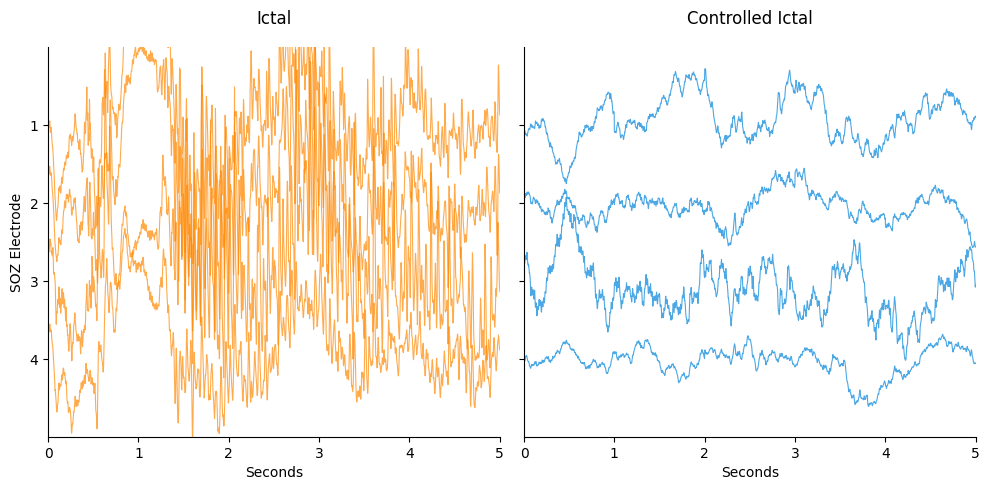


Amplitude reduction for displayed SOZ Electrodes:
Raw amplitude: 159.03 µV
Controlled amplitude: 60.54 µV
Reduction: 61.93%


In [4]:
# Raw vs Controlled SOZ electrodes (HUP68 block 1, first 4 SOZ electrodes)
patient = 'HUP68'
seizure = 3

ictal_data_path = os.path.join(raw_data_path, patient, f"{patient}-ictal-block-{seizure}.mat")
ctrl_data_path = os.path.join(main_pathname, patient, f"controlled_data_block_{seizure}.mat")
ictal_data = scipy.io.loadmat(ictal_data_path)
ctrl_data = scipy.io.loadmat(ctrl_data_path)
raw_signal = ictal_data['evData']
ctrl_signal = ctrl_data['evData']

soz_indices = patient_soz_indices[patient]  
selected_indices = soz_indices[:4]

fs = int(np.ceil(ictal_data['Fs'][0][0]))
window_sec = 5
t = np.linspace(0, window_sec, window_sec * fs)

# Data slices
start_ictal = int(20 * fs)
end_ictal = start_ictal + window_sec * fs
start_ctrl = 0
end_ctrl = window_sec * fs

n_channels = len(selected_indices)

offset = 300  # in microvolts

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# Ictal subplot
for i, ch_idx in enumerate(selected_indices):

    ictal_trace = raw_signal[ch_idx, start_ictal:end_ictal] + i * offset
    axes[0].plot(t, ictal_trace, color=colors[2], linewidth=0.8, alpha = .7) 

axes[0].text(0.5, 1.05, 'Ictal', transform=axes[0].transAxes, ha='center', va='bottom', fontsize=12)
axes[0].set_xlabel('Seconds')
axes[0].set_xlim(0, 5)
axes[0].set_xticks([0, 1, 2, 3, 4, 5])
axes[0].set_ylim(-offset, n_channels * offset)
axes[0].set_yticks([i * offset for i in range(n_channels)])
axes[0].set_yticklabels([1, 2, 3, 4])
axes[0].set_ylabel('SOZ Electrode')
axes[0].invert_yaxis() 

# Controlled subplot
for i, ch_idx in enumerate(selected_indices):

    ctrl_trace = ctrl_signal[ch_idx, start_ctrl:end_ctrl] + i * offset
    axes[1].plot(t, ctrl_trace, color=colors[0], linewidth=0.8, alpha = .7) 

axes[1].text(0.5, 1.05, 'Controlled Ictal', transform=axes[1].transAxes, ha='center', va='bottom', fontsize=12)
axes[1].set_xlabel('Seconds')
axes[1].set_xlim(0, 5)
axes[1].set_xticks([0, 1, 2, 3, 4, 5])

# Remove top and right spines for cleaner look
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(os.path.join(output_path, patient, f"block{seizure}_raw_vs_ctrl.pdf"), bbox_inches='tight')
plt.show()

raw_soz_shown = raw_signal[selected_indices, start_ictal:end_ictal]
ctrl_soz_shown = ctrl_signal[selected_indices, start_ctrl:end_ctrl]

raw_amplitude = np.mean(np.abs(raw_soz_shown))
ctrl_amplitude = np.mean(np.abs(ctrl_soz_shown))

pct_reduction = ((raw_amplitude - ctrl_amplitude) / raw_amplitude) * 100

print(f"\nAmplitude reduction for displayed SOZ Electrodes:")
print(f"Raw amplitude: {raw_amplitude:.2f} µV")
print(f"Controlled amplitude: {ctrl_amplitude:.2f} µV")
print(f"Reduction: {pct_reduction:.2f}%")

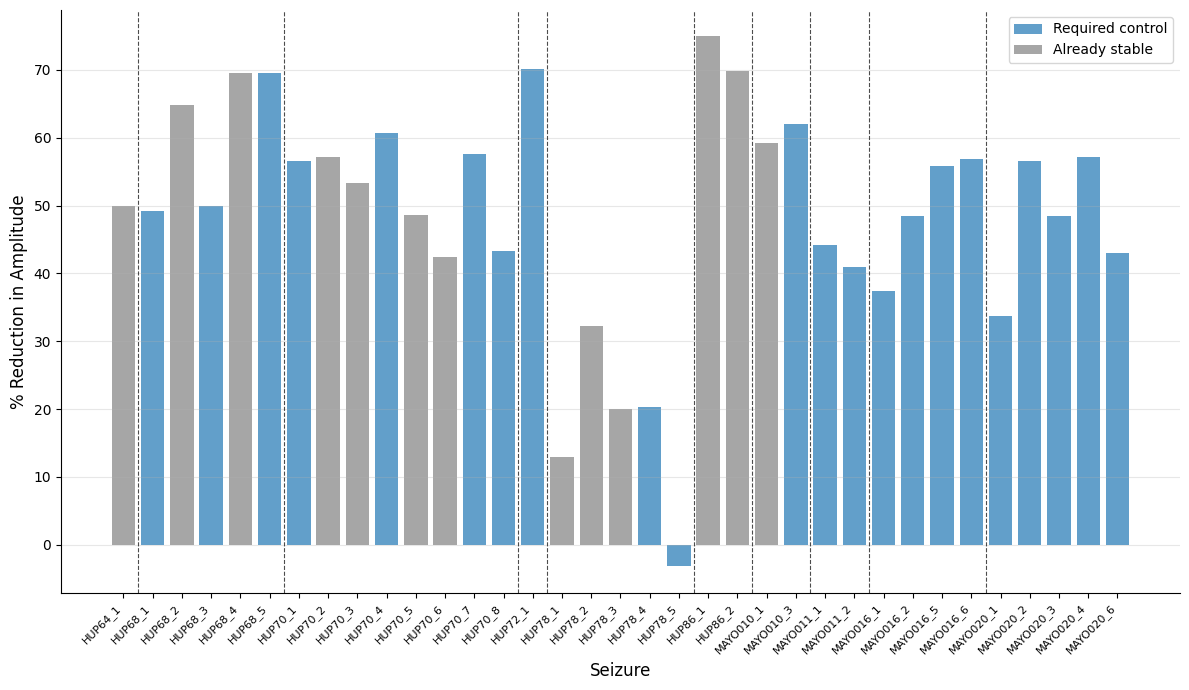


Total seizures analyzed: 35
Required control: 22
Already stable: 13
Mean reduction (required control): 48.12% ± 15.95%
Mean reduction (already stable): 50.38% ± 18.41%
Overall mean reduction: 48.96%
Overall std: 16.94%


In [7]:
# % Reduction of signal amplitude in SOZ electrodes after control (blue required control, gray already stable)

percentage_reductions = []
seizure_labels = []
bar_colors = []

for patient in patients: 
    for seizure in range(1, 9): 
        ictal_data_path = os.path.join(raw_data_path, patient, f"{patient}-ictal-block-{seizure}.mat")
        ctrl_data_path = os.path.join(main_pathname, patient, f"controlled_data_block_{seizure}.mat")
        
        if os.path.exists(ictal_data_path) and os.path.exists(ctrl_data_path):
            ictal_data = scipy.io.loadmat(ictal_data_path)
            ctrl_data = scipy.io.loadmat(ctrl_data_path)
            raw_signal = ictal_data['evData']
            ctrl_signal = ctrl_data['evData']
            fs = int(np.ceil(ictal_data['Fs'][0][0]))

            ictal_duration = 20 
            start_ictal = int(20 * fs)
            end_ictal = start_ictal + ictal_duration * fs
            start_ctrl = 0
            end_ctrl = ictal_duration * fs

            raw_all = raw_signal[:, start_ictal:end_ictal]
            ctrl_all = ctrl_signal[:, start_ctrl:end_ctrl]

            raw_amplitude = np.mean(np.abs(raw_all))
            ctrl_amplitude = np.mean(np.abs(ctrl_all))

            pct_reduction = ((raw_amplitude - ctrl_amplitude) / raw_amplitude) * 100

            is_stable = ((stable_seizures_df['patient'] == patient) & 
                        (stable_seizures_df['seizure'] == seizure)).any()

            percentage_reductions.append(pct_reduction)
            seizure_labels.append(f"{patient}_{seizure}")
            bar_colors.append('gray' if is_stable else '#1F77B4')

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(range(len(percentage_reductions)), percentage_reductions, color=bar_colors, alpha=0.7)

ax.set_xlabel('Seizure', fontsize=12)
ax.set_ylabel('% Reduction in Amplitude', fontsize=12)
ax.set_xticks(range(len(seizure_labels)))
ax.set_xticklabels(seizure_labels, rotation=45, ha = 'right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1F77B4', alpha=0.7, label='Required control'),
                   Patch(facecolor='gray', alpha=0.7, label='Already stable')]
ax.legend(handles=legend_elements, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

patient_boundaries = []
current_patient = None
for idx, label in enumerate(seizure_labels):
    patient_name = label.split('_')[0]
    if current_patient is not None and patient_name != current_patient:
        patient_boundaries.append(idx)
    current_patient = patient_name

for boundary in patient_boundaries:
    ax.axvline(boundary - 0.5, color='black', linestyle='--', alpha=0.7, linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_path, "all_channels_amplitude_reduction.pdf"), bbox_inches='tight')
plt.show()

print(f"\nTotal seizures analyzed: {len(percentage_reductions)}")
print(f"Required control: {sum([c == '#1F77B4' for c in bar_colors])}")
print(f"Already stable: {sum([c == 'gray' for c in bar_colors])}")

mean_reduction_control = np.mean([r for r, c in zip(percentage_reductions, bar_colors) if c == '#1F77B4'])
std_reduction_control = np.std([r for r, c in zip(percentage_reductions, bar_colors) if c == '#1F77B4'])

mean_reduction_stable = np.mean([r for r, c in zip(percentage_reductions, bar_colors) if c == 'gray'])
std_reduction_stable = np.std([r for r, c in zip(percentage_reductions, bar_colors) if c == 'gray'])

print(f"Mean reduction (required control): {mean_reduction_control:.2f}% ± {std_reduction_control:.2f}%")
print(f"Mean reduction (already stable): {mean_reduction_stable:.2f}% ± {std_reduction_stable:.2f}%")
        
print(f"Overall mean reduction: {np.mean(percentage_reductions):.2f}%")
print(f"Overall std: {np.std(percentage_reductions):.2f}%")